# Chapter 10
# Image Classification and Object Detection

---

## **Part I: Image Classification**

### With Vision Transformer (ViT)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

C:\Users\sandi\anaconda3\envs\torch-gpu\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sandi\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Predicted Class: Egyptian cat


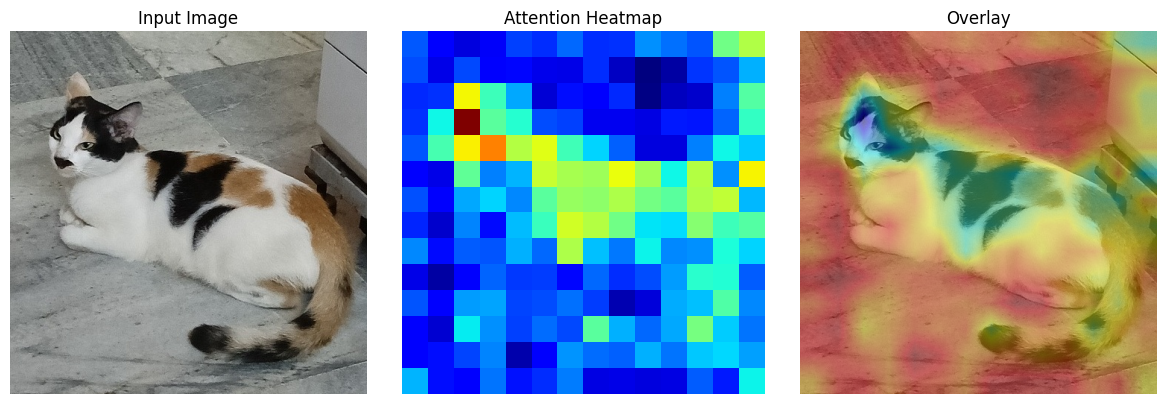

In [1]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification

model_name = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(
    model_name,
    output_attentions=True
)

model.eval()

# Load image
image_path = "images/cat.jpg"
image = Image.open(image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

logits = outputs.logits
attentions = outputs.attentions   # tuple: (layers, batch, heads, tokens, tokens)

# -----------------------------
# 1. Get CLS attention rollout
# -----------------------------
def rollout_attention(attentions):
    # attentions: list of layers
    result = torch.eye(attentions[0].shape[-1])

    for attn in attentions:
        attn_heads_fused = attn.mean(dim=1)[0]  # average heads
        attn_heads_fused += torch.eye(attn_heads_fused.shape[-1])  # residual
        attn_heads_fused /= attn_heads_fused.sum(dim=-1, keepdim=True)

        result = torch.matmul(attn_heads_fused, result)

    # CLS token is index 0
    mask = result[0, 1:]
    return mask

mask = rollout_attention(attentions)

# -----------------------------
# 2. Reshape to patch grid
# -----------------------------
num_patches = mask.shape[0]
grid_size = int(np.sqrt(num_patches))

heatmap = mask.reshape(grid_size, grid_size).cpu().numpy()

# Normalize
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

# -----------------------------
# 3. Resize heatmap to image
# -----------------------------
img = np.array(image)
heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

heatmap_color = cv2.applyColorMap(
    np.uint8(255 * heatmap_resized),
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

# -----------------------------
# 4. Prediction
# -----------------------------
pred_class = logits.argmax(-1).item()
label = model.config.id2label[pred_class]

print("Predicted Class:", label)

# -----------------------------
# 5. Show result
# -----------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Attention Heatmap")
plt.imshow(heatmap, cmap="jet")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

### Flower Classification

In [ ]:
import gradio as gr
import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForImageClassification

FLOWER_LABELS = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells",
    "sweet pea", "english marigold", "tiger lily", "moon orchid",
    "bird of paradise", "monkshood", "globe thistle", "snapdragon",
    "colt's foot", "king protea", "spear thistle", "yellow iris",
    "globe flower", "purple coneflower", "peruvian lily",
    "balloon flower", "giant white arum lily", "fire lily",
    "pincushion flower", "fritillary", "red ginger", "grape hyacinth",
    "corn poppy", "prince of wales feathers", "stemless gentian",
    "artichoke", "sweet william", "carnation", "garden phlox",
    "love in the mist", "cosmos", "alpine sea holly",
    "ruby-lipped cattleya", "cape flower", "great masterwort",
    "siam tulip", "lenten rose", "barbeton daisy", "daffodil",
    "sword lily", "poinsettia", "bolero deep blue", "wallflower",
    "marigold", "buttercup", "oxeye daisy", "common dandelion",
    "petunia", "wild pansy", "primula", "sunflower", "pelargonium",
    "bishop of llandaff", "gaura", "geranium", "orange dahlia",
    "pink-yellow dahlia", "cautleya spicata", "japanese anemone",
    "black-eyed susan", "silverbush", "californian poppy",
    "osteospermum", "spring crocus", "iris", "windflower",
    "tree poppy", "gazania", "azalea", "water lily", "rose",
    "thorn apple", "morning glory", "passion flower", "lotus",
    "toad lily", "anthurium", "frangipani", "clematis",
    "hibiscus", "columbine", "desert-rose", "tree mallow",
    "magnolia", "cyclamen", "watercress", "canna lily",
    "hippeastrum", "bee balm", "pink quill", "foxglove",
    "bougainvillea", "camellia", "mallow", "mexican petunia",
    "bromelia", "blanket flower", "trumpet creeper",
    "blackberry lily"
]

# Load Model (BEST CHOICE)
model_name = "MaulikMadhavi/vit-base-flowers102"

#processor = AutoImageProcessor.from_pretrained(model_name)
from transformers import ViTImageProcessor
processor = ViTImageProcessor.from_pretrained(model_name)

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    output_attentions=True
)

model.eval()

# Attention Rollout
def rollout_attention(attentions):
    result = torch.eye(attentions[0].shape[-1])

    for attn in attentions:
        attn_heads_fused = attn.mean(dim=1)[0]
        attn_heads_fused += torch.eye(attn_heads_fused.shape[-1])
        attn_heads_fused /= attn_heads_fused.sum(dim=-1, keepdim=True)
        result = torch.matmul(attn_heads_fused, result)

    mask = result[0, 1:]
    return mask


# Main Function
def classify_and_explain(image):

    image = image.convert("RGB")
    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    logits = outputs.logits
    attentions = outputs.attentions

    # Top-5 predictions
    probs = torch.nn.functional.softmax(logits, dim=-1)[0]
    top5 = torch.topk(probs, k=5)

    results = {}
    for i in range(5):
        idx = top5.indices[i].item()
        score = top5.values[i].item()
        label = FLOWER_LABELS[idx-1]
        results[label] = float(score)

    # Attention Heatmap
    mask = rollout_attention(attentions)

    num_patches = mask.shape[0]
    grid_size = int(np.sqrt(num_patches))

    heatmap = mask.reshape(grid_size, grid_size).cpu().numpy()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

    img_np = np.array(image)
    heatmap_resized = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))

    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized),
        cv2.COLORMAP_JET
    )

    overlay = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)

    return results, overlay


# Gradio UI
title = "🌸 Flower Classification with ViT + Attention"

description = """
Upload a flower image to:
- 🌼 Classify using Vision Transformer  
- 🔝 View Top-5 predictions  
- 🔥 Visualize attention heatmap (model explanation)  
"""

interface = gr.Interface(
    fn=classify_and_explain,
    inputs=gr.Image(type="pil", label="Upload Flower Image"),
    outputs=[
        gr.Label(num_top_classes=5, label="Top Predictions"),
        gr.Image(label="Attention Heatmap Overlay")
    ],
    title=title,
    description=description,
)

# Launch
interface.launch()

![](images/rose_right_clf.png)
![](images/passion_right_clf.png)
![](images/dahlia_wrong_clf.png)

### **with Swin Transformer**

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoImageProcessor, SwinForImageClassification

# -----------------------------
# Load Swin Transformer
# -----------------------------
model_name = "microsoft/swin-base-patch4-window7-224"

processor = AutoImageProcessor.from_pretrained(model_name)
model = SwinForImageClassification.from_pretrained(model_name)

model.eval()

# -----------------------------
# Load image
# -----------------------------
image_path = "images/parrot.png"
image = Image.open(image_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt")

# Enable gradients for saliency
inputs["pixel_values"].requires_grad = True

# -----------------------------
# Forward pass
# -----------------------------
outputs = model(**inputs)
logits = outputs.logits

pred_class = logits.argmax(dim=-1).item()
score = logits[0, pred_class]

print("Predicted Class:", model.config.id2label[pred_class])

# -----------------------------
# Backprop for saliency
# -----------------------------
model.zero_grad()
score.backward()

grads = inputs["pixel_values"].grad  # (1, 3, H, W)

# Convert gradients → importance map
saliency = grads.abs().mean(dim=1)[0].detach().numpy()

# Normalize
saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

# -----------------------------
# Resize heatmap to image size
# -----------------------------
img = np.array(image)

heatmap = cv2.resize(saliency, (img.shape[1], img.shape[0]))

heatmap_color = cv2.applyColorMap(
    np.uint8(255 * heatmap),
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

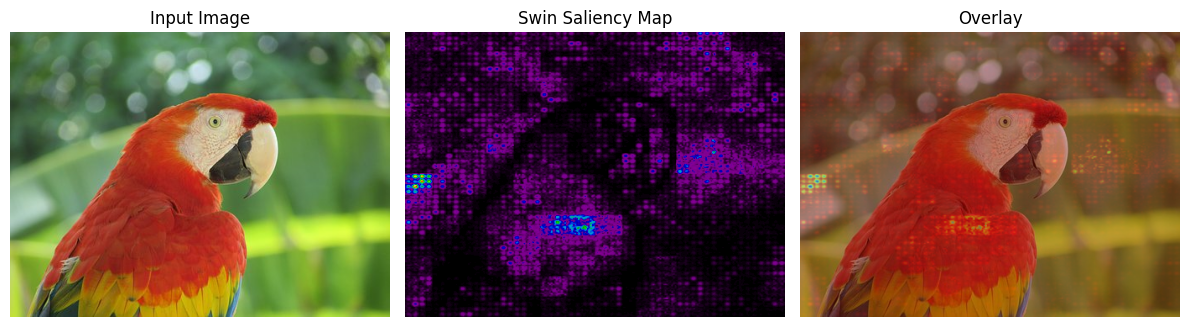

In [9]:
# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Swin Saliency Map")
plt.imshow(heatmap, cmap="nipy_spectral")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

### Few Shot Learning with CLIP

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


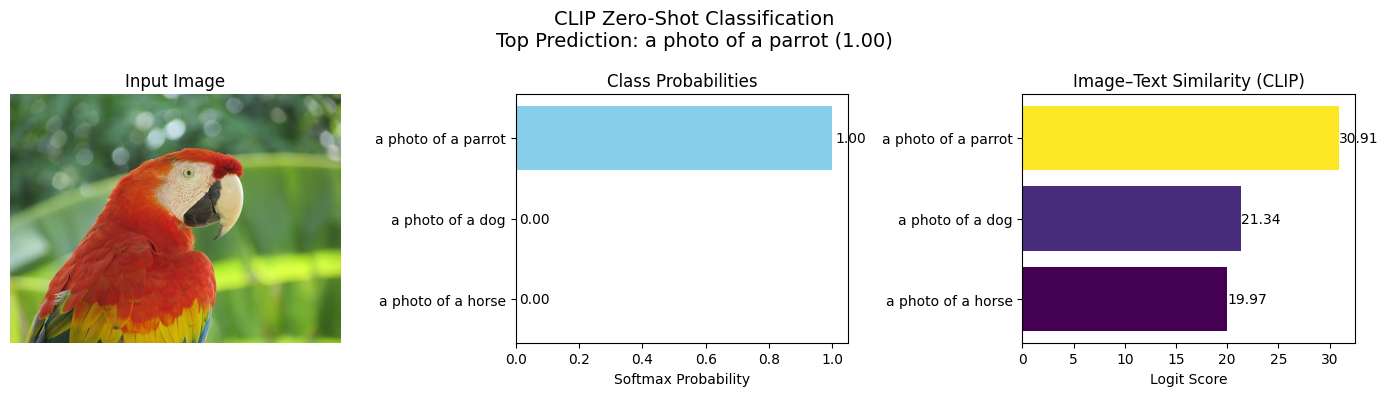

In [8]:
%matplotlib inline
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

# -----------------------------
# Load CLIP
# -----------------------------
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

model.eval()

# -----------------------------
# Load Image
# -----------------------------
image = Image.open("images/parrot.png").convert("RGB")

classes = ["a photo of a dog", "a photo of a horse", "a photo of a parrot"]

inputs = processor(text=classes, images=image, return_tensors="pt", padding=True)

# -----------------------------
# Hook for Grad-CAM
# -----------------------------
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# Hook LAST attention block output (better than encoder layer output)
target_layer = model.vision_model.encoder.layers[-1].layer_norm1
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# -----------------------------
# Forward
# -----------------------------
outputs = model(**inputs)
logits = outputs.logits_per_image
probs = logits.softmax(dim=1)

class_idx = torch.argmax(probs, dim=1).item()

# -----------------------------
# Backward
# -----------------------------
model.zero_grad()
logits[0, class_idx].backward()

# -----------------------------
# Get activations & gradients
# -----------------------------
acts = activations[0]   # [1, tokens, dim]
grads = gradients[0]    # same shape

# Remove CLS token
acts = acts[:, 1:, :]
grads = grads[:, 1:, :]

# -----------------------------
# Compute weights (important fix)
# -----------------------------
weights = grads.mean(dim=1)  # [1, dim]

# Weighted sum across channels
cam = (acts * weights.unsqueeze(1)).sum(dim=2)

# -----------------------------
# Reshape to spatial grid
# -----------------------------
num_tokens = cam.shape[1]
grid_size = int(num_tokens ** 0.5)

cam = cam.reshape(grid_size, grid_size).detach().cpu().numpy()

# -----------------------------
# Normalize (FIX: avoid flat map)
# -----------------------------
cam = cam - cam.min()
if cam.max() > 0:
    cam = cam / cam.max()

# -----------------------------
# Resize & overlay
# -----------------------------
img_np = np.array(image)

cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))

heatmap = cv2.applyColorMap(
    np.uint8(255 * cam_resized),
    cv2.COLORMAP_JET
)

overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

# -----------------------------
# Plot
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Prepare Data
# -----------------------------
labels = classes

# Probabilities
probs_np = probs[0].detach().cpu().numpy()

# Raw similarities (important!)
logits_np = logits[0].detach().cpu().numpy()

# Normalize similarities (for visualization only)
sim_norm = (logits_np - logits_np.min()) / (logits_np.max() - logits_np.min() + 1e-8)

# Sort by probability
sorted_idx = np.argsort(probs_np)[::-1]

labels_sorted = [labels[i] for i in sorted_idx]
probs_sorted = probs_np[sorted_idx]
logits_sorted = logits_np[sorted_idx]
sim_sorted = sim_norm[sorted_idx]

top_label = labels_sorted[0]
top_prob = probs_sorted[0]

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = np.array(axes).reshape(-1)

# ---- Image ----
axes[0].imshow(image)
axes[0].set_title("Input Image")
axes[0].axis("off")

# ---- Probability Bar ----
y_pos = np.arange(len(labels_sorted))
axes[1].barh(y_pos, probs_sorted, color="skyblue")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(labels_sorted)
axes[1].invert_yaxis()
axes[1].set_title("Class Probabilities")
axes[1].set_xlabel("Softmax Probability")

# annotate
for i, v in enumerate(probs_sorted):
    axes[1].text(v + 0.01, i, f"{v:.2f}", va='center')

# ---- Similarity Bar (CLIP core idea) ----
colors = plt.cm.viridis(sim_sorted)  # color encodes similarity

axes[2].barh(y_pos, logits_sorted, color=colors)
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(labels_sorted)
axes[2].invert_yaxis()
axes[2].set_title("Image–Text Similarity (CLIP)")
axes[2].set_xlabel("Logit Score")

# annotate
for i, v in enumerate(logits_sorted):
    axes[2].text(v + 0.01, i, f"{v:.2f}", va='center')

# -----------------------------
# Global Title
# -----------------------------
plt.suptitle(
    f"CLIP Zero-Shot Classification\nTop Prediction: {top_label} ({top_prob:.2f})",
    fontsize=14
)

plt.tight_layout()
plt.show()

### with Dinov2

In [13]:
import torch
import timm
import numpy as np
from PIL import Image
import torchvision.transforms as T

# -----------------------------
# Load DINOv2 (from timm)
# -----------------------------
model = timm.create_model("vit_base_patch14_dinov2.lvd142m", pretrained=True)
model.eval()

# Remove classification head → use embeddings
model.reset_classifier(0)

# -----------------------------
# Transform
# -----------------------------
transform = T.Compose([
    T.Resize((518, 518)),  # ✅ FIX
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),  # better for pretrained models
                std=(0.229, 0.224, 0.225))
])

def get_embedding(path):
    img = Image.open(path).convert("RGB")
    x = transform(img).unsqueeze(0)
    with torch.no_grad():
        emb = model(x)
    return emb.squeeze()

# -----------------------------
# Few-shot support set
# -----------------------------
support_set = {
    "dog": ["images/dog1.png", "images/dog2.png"],
    "cat": ["images/cat1.png", "images/cat2.png"]
}

# Build prototypes
prototypes = {}
for cls, paths in support_set.items():
    embs = [get_embedding(p) for p in paths]
    prototypes[cls] = torch.stack(embs).mean(0)

# -----------------------------
# Query
# -----------------------------
query_emb = get_embedding("images/lab.png")

# Compute similarity
scores = {}
for cls, proto in prototypes.items():
    sim = torch.nn.functional.cosine_similarity(query_emb, proto, dim=0)
    scores[cls] = sim.item()

# Sort
scores = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))

print("Prediction:")
for k, v in scores.items():
    print(f"{k}: {v:.4f}")

Prediction:
dog: 0.1764
cat: 0.1138


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

def visualize_dinov2(query_path, support_set, prototypes, scores, top_k=2):

    # -----------------------------
    # Sort scores
    # -----------------------------
    sorted_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_items = sorted_items[:top_k]

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(1, top_k + 1, figsize=(4*(top_k+1), 4))
    axes = np.array(axes).reshape(-1)

    # ---- Query Image ----
    axes[0].imshow(Image.open(query_path))
    axes[0].set_title("Query Image")
    axes[0].axis("off")

    # ---- Top Matches ----
    for i, (cls, score) in enumerate(top_items):
        img_path = support_set[cls][0]  # show first support image

        axes[i+1].imshow(Image.open(img_path))
        axes[i+1].set_title(f"{cls}\nSimilarity: {score:.2f}")
        axes[i+1].axis("off")

    # -----------------------------
    # Title
    # -----------------------------
    best_class, best_score = top_items[0]

    plt.suptitle(
        f"DINOv2 Few-Shot Classification\nPrediction: {best_class} ({best_score:.2f})",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

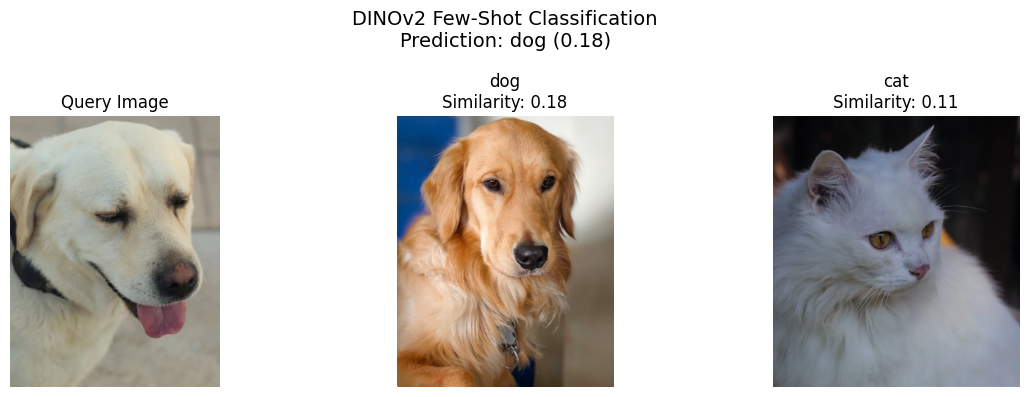

In [15]:
visualize_dinov2(
    query_path="images/lab.png",
    support_set=support_set,
    prototypes=prototypes,
    scores=scores,
    top_k=2
)

### with Siamese Network

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image

# -----------------------------
# Siamese Model
# -----------------------------
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image

# -----------------------------
# Siamese Model (FIXED)
# -----------------------------
class SiameseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # ✅ FIX
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 256),
            nn.ReLU()
        )

    def encode(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x

    def forward(self, x1, x2):
        f1 = self.encode(x1)
        f2 = self.encode(x2)
        return f1, f2
        
# -----------------------------
# Distance function
# -----------------------------
def contrastive_loss(f1, f2, label, margin=1.0):
    dist = torch.norm(f1 - f2, dim=1)
    loss = label * dist**2 + (1-label) * torch.clamp(margin - dist, min=0)**2
    return loss.mean()

# -----------------------------
# Transform
# -----------------------------
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

def load_img(path):
    return transform(Image.open(path).convert("RGB")).unsqueeze(0)

# -----------------------------
# Initialize
# -----------------------------
model = SiameseNet()

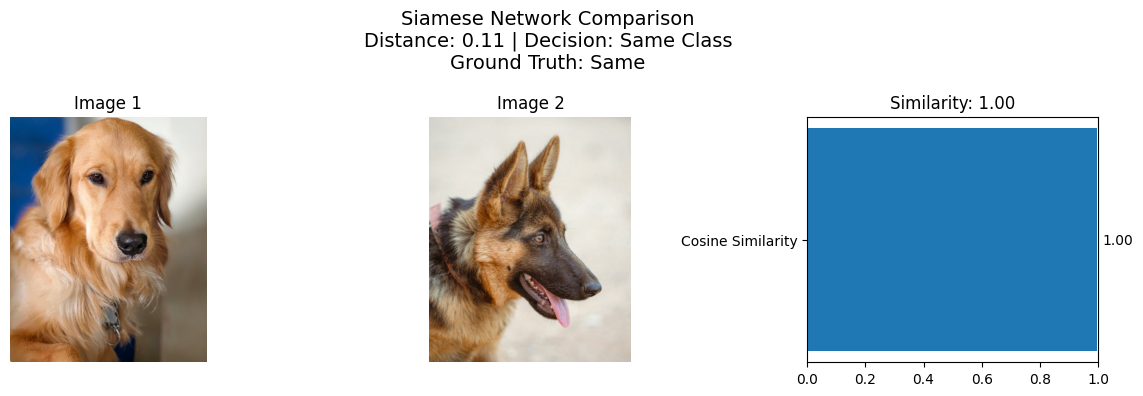

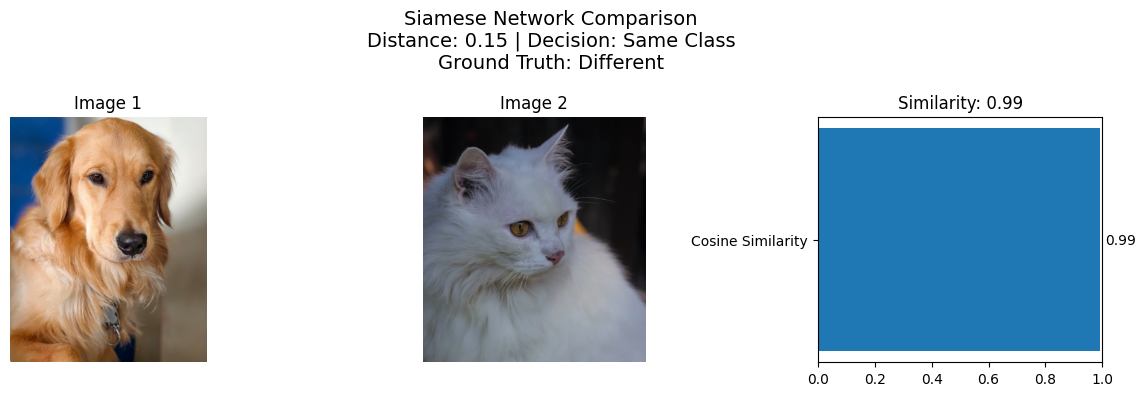

In [2]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

def visualize_siamese(img_path1, img_path2, model, label=None):

    # Load images
    img1 = load_img(img_path1)
    img2 = load_img(img_path2)

    # Forward pass
    with torch.no_grad():
        f1, f2 = model(img1, img2)

    # Distance & similarity
    dist = torch.norm(f1 - f2, dim=1).item()
    sim = F.cosine_similarity(f1, f2).item()

    # Decision
    decision = "Same Class" if sim > 0.5 else "Different Class"

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes = np.array(axes).reshape(-1)

    # ---- Image 1 ----
    axes[0].imshow(Image.open(img_path1))
    axes[0].set_title("Image 1")
    axes[0].axis("off")

    # ---- Image 2 ----
    axes[1].imshow(Image.open(img_path2))
    axes[1].set_title("Image 2")
    axes[1].axis("off")

    # ---- Similarity Bar ----
    axes[2].barh(["Cosine Similarity"], [sim])
    axes[2].set_xlim(0, 1)
    axes[2].set_title(f"Similarity: {sim:.2f}")
    
    # Annotate
    axes[2].text(sim + 0.02, 0, f"{sim:.2f}", va='center')

    # -----------------------------
    # Global Title
    # -----------------------------
    title = f"Siamese Network Comparison\nDistance: {dist:.2f} | Decision: {decision}"
    
    if label is not None:
        title += f"\nGround Truth: {'Same' if label==1 else 'Different'}"

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_siamese("images/dog1.png", "images/dog2.png", model, label=1)
visualize_siamese("images/dog1.png", "images/cat1.png", model, label=0)

### Face Recognition

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as T
from torchvision import models

# -----------------------------
# Config
# -----------------------------
gallery_dir = "images/gallery"   # structure: gallery/person_name/*.jpg
query_image = "images/galleryme.jpg" # single face image
threshold = 0.6           # cosine similarity threshold (tune)

device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# Transform (simple; assume faces are roughly cropped)
# -----------------------------
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))
])

def load_image(path):
    return transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)

# -----------------------------
# Siamese Encoder (ResNet backbone)
# -----------------------------
class FaceEncoder(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # remove classification head
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        feat = self.backbone(x)          # [B, 512]
        emb = self.projector(feat)       # [B, D]
        emb = F.normalize(emb, dim=1)    # L2-normalize
        return emb

# -----------------------------
# Build model
# -----------------------------
model = FaceEncoder(embedding_dim=128).to(device)
model.eval()

# -----------------------------
# Build gallery (embeddings per person)
# -----------------------------
def build_gallery_embeddings(root_dir):
    gallery = {}
    with torch.no_grad():
        for person in os.listdir(root_dir):
            person_dir = os.path.join(root_dir, person)
            if not os.path.isdir(person_dir):
                continue

            embs = []
            for img_name in os.listdir(person_dir):
                if not img_name.lower().endswith((".jpg",".jpeg",".png")):
                    continue
                img_path = os.path.join(person_dir, img_name)
                x = load_image(img_path)
                emb = model(x)           # [1, D]
                embs.append(emb.squeeze(0))

            if len(embs) > 0:
                # average embedding (prototype)
                gallery[person] = torch.stack(embs).mean(0)
    return gallery

gallery = build_gallery_embeddings(gallery_dir)

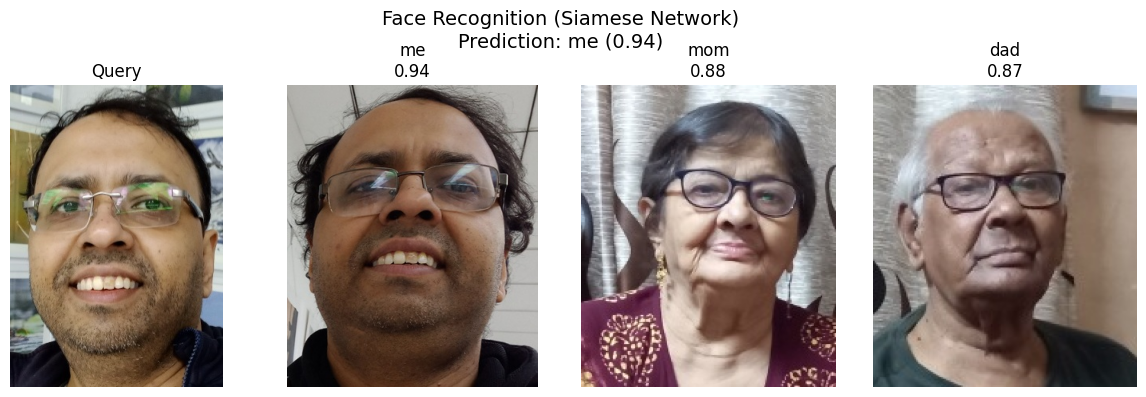

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

def visualize_recognition(query_path, gallery, model, threshold=0.6, top_k=3):

    # -----------------------------
    # Compute query embedding
    # -----------------------------
    with torch.no_grad():
        q = load_image(query_path)
        q_emb = model(q).squeeze(0)

    # -----------------------------
    # Compute similarities
    # -----------------------------
    results = []
    for person, g_emb in gallery.items():
        sim = torch.nn.functional.cosine_similarity(q_emb, g_emb, dim=0).item()
        results.append((person, sim))

    # Sort
    results = sorted(results, key=lambda x: x[1], reverse=True)
    top_results = results[:top_k]

    best_person, best_score = top_results[0]

    if best_score < threshold:
        final_label = "Unknown"
    else:
        final_label = best_person

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(12, 4))

    # ---- Query Image ----
    plt.subplot(1, top_k + 1, 1)
    plt.imshow(Image.open(query_path))
    plt.title("Query")
    plt.axis("off")

    # ---- Top Matches ----
    for i, (person, score) in enumerate(top_results):

        # pick first image of that person
        person_dir = os.path.join("images", "gallery", person)
        img_name = os.listdir(person_dir)[0]
        img_path = os.path.join(person_dir, img_name)

        plt.subplot(1, top_k + 1, i + 2)
        plt.imshow(Image.open(img_path))
        plt.title(f"{person}\n{score:.2f}")
        plt.axis("off")

    # ---- Global Title ----
    plt.suptitle(
        f"Face Recognition (Siamese Network)\nPrediction: {final_label} ({best_score:.2f})",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


visualize_recognition(
    query_path="images/me.jpg",
    gallery=gallery,
    model=model,
    threshold=0.6,
    top_k=3
)

## **Part II: Object Detection**

---

### **with RetinaNet**

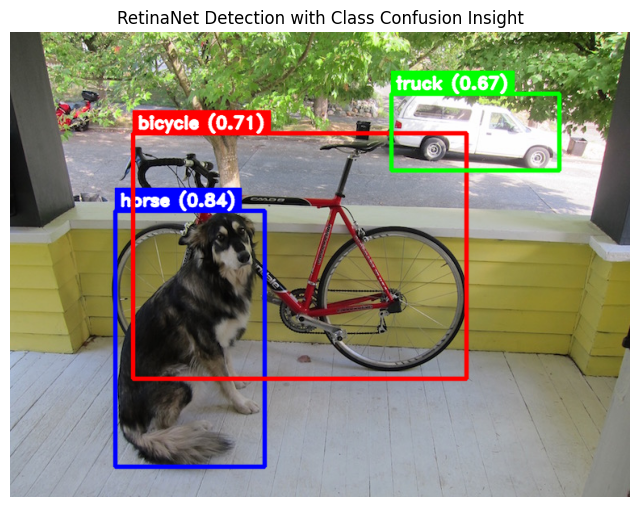

In [25]:
import torch
import torchvision
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# -----------------------------
# Load RetinaNet
# -----------------------------
model = torchvision.models.detection.retinanet_resnet50_fpn(weights="DEFAULT")
model.eval()

# -----------------------------
# COCO Classes
# -----------------------------
COCO_CLASSES = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light", "fire hydrant",
    "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse",
    "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis",
    "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "wine glass",
    "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza",
    "donut", "cake", "chair", "couch", "potted plant", "bed",
    "dining table", "toilet", "tv", "laptop", "mouse", "remote",
    "keyboard", "cell phone", "microwave", "oven", "toaster",
    "sink", "refrigerator", "book", "clock", "vase", "scissors",
    "teddy bear", "hair drier", "toothbrush"
]

# -----------------------------
# Vibrant Colors (HSV)
# -----------------------------
def generate_colors(n):
    colors = []
    for i in range(n):
        hue = int(180 * i / n)
        hsv = np.uint8([[[hue, 255, 255]]])
        rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)[0][0]
        colors.append(rgb.tolist())
    return colors

# -----------------------------
# Load Image
# -----------------------------
image_path = "images/dog_cycle.jpg"
image = Image.open(image_path).convert("RGB")

transform = transforms.Compose([transforms.ToTensor()])
img_tensor = transform(image)

# -----------------------------
# Inference
# -----------------------------
with torch.no_grad():
    outputs = model([img_tensor])[0]

boxes = outputs["boxes"]
scores = outputs["scores"]
labels = outputs["labels"]

# -----------------------------
# Filter detections
# -----------------------------
threshold = 0.6
keep = scores >= threshold

boxes = boxes[keep]
scores = scores[keep]
labels = labels[keep]

# -----------------------------
# Assign colors per detected class
# -----------------------------
unique_labels = sorted(set(labels.cpu().numpy().tolist()))
colors = generate_colors(len(unique_labels))
COLOR_MAP = {cls: color for cls, color in zip(unique_labels, colors)}

# -----------------------------
# Visualization
# -----------------------------
img = np.array(image).copy()

for box, score, label in zip(boxes, scores, labels):

    label_id = int(label)  # 🔑 FIX

    x1, y1, x2, y2 = map(int, box.tolist())
    class_name = COCO_CLASSES[label_id]
    color = COLOR_MAP[label_id]

    # Draw box
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3, lineType=cv2.LINE_AA)

    text = f"{class_name} ({score:.2f})"

    font = cv2.FONT_HERSHEY_DUPLEX
    font_scale = 0.7
    thickness = 2
    pad = 6

    (w, h), _ = cv2.getTextSize(text, font, font_scale, thickness)

    cv2.rectangle(img,
                  (x1, y1 - h - 2*pad),
                  (x1 + w + 2*pad, y1),
                  color, -1, lineType=cv2.LINE_AA)

    cv2.putText(img, text,
                (x1 + pad, y1 - pad),
                font, font_scale,
                (255, 255, 255),
                thickness,
                lineType=cv2.LINE_AA)

# -----------------------------
# Show Result
# -----------------------------
plt.figure(figsize=(8, 8))
plt.imshow(img.astype(np.uint8))
plt.title("RetinaNet Detection with Class Confusion Insight")
plt.axis("off")
plt.show()

### **with Mask R-CNN**

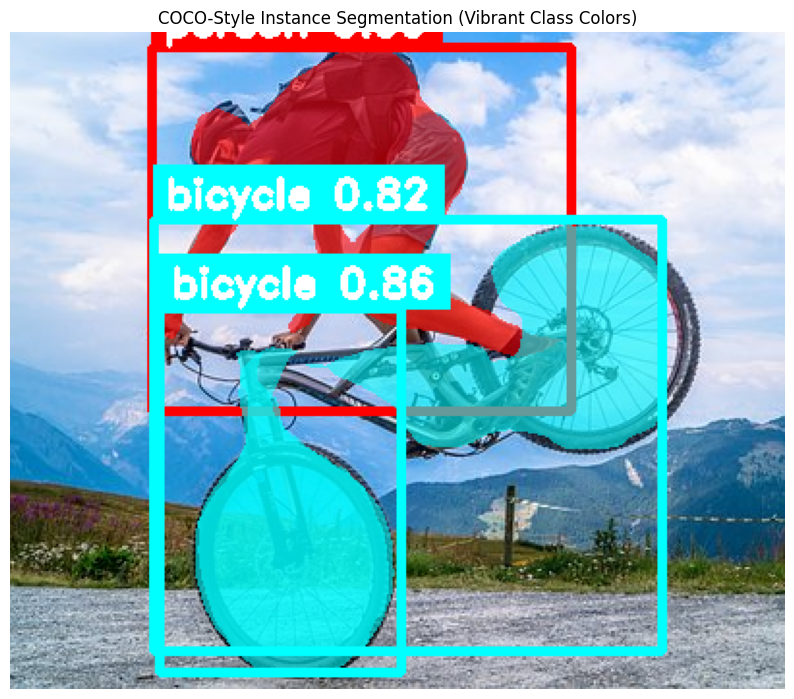

In [22]:
import torch
import torchvision
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# -----------------------------
# Load Mask R-CNN model
# -----------------------------
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
model.eval()

# -----------------------------
# COCO class labels
# -----------------------------
COCO_CLASSES = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light", "fire hydrant",
    "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse",
    "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis",
    "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "wine glass",
    "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza",
    "donut", "cake", "chair", "couch", "potted plant", "bed",
    "dining table", "toilet", "tv", "laptop", "mouse", "remote",
    "keyboard", "cell phone", "microwave", "oven", "toaster",
    "sink", "refrigerator", "book", "clock", "vase", "scissors",
    "teddy bear", "hair drier", "toothbrush"
]

# -----------------------------
# Generate vibrant colors (HSV)
# -----------------------------
def generate_vibrant_colors(n):
    colors = []
    for i in range(n):
        hue = int(180 * i / n)
        hsv = np.uint8([[[hue, 255, 255]]])
        rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)[0][0]
        colors.append(rgb.tolist())
    return colors

# -----------------------------
# Load image
# -----------------------------
image_path = "images/cycle.jpg"  # change this
image = Image.open(image_path).convert("RGB")

transform = transforms.Compose([transforms.ToTensor()])
img_tensor = transform(image)

# -----------------------------
# Inference
# -----------------------------
with torch.no_grad():
    outputs = model([img_tensor])[0]

boxes = outputs["boxes"].cpu().numpy()
scores = outputs["scores"].cpu().numpy()
labels = outputs["labels"].cpu().numpy()
masks = outputs["masks"].cpu().numpy()

# -----------------------------
# Filter detections
# -----------------------------
threshold = 0.5
keep = scores >= threshold

boxes = boxes[keep]
scores = scores[keep]
labels = labels[keep]
masks = masks[keep]

# -----------------------------
# Assign colors ONLY to detected classes
# -----------------------------
unique_labels = sorted(set(labels.tolist()))
colors = generate_vibrant_colors(len(unique_labels))
COLOR_MAP = {cls: color for cls, color in zip(unique_labels, colors)}

# -----------------------------
# Visualization
# -----------------------------
img = np.array(image).copy()

for box, score, label, mask in zip(boxes, scores, labels, masks):

    x1, y1, x2, y2 = map(int, box)
    class_name = COCO_CLASSES[label]
    color = COLOR_MAP[label]

    # ---- Mask ----
    mask = (mask[0] > 0.6).astype(np.uint8)
    mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

    colored_mask = np.zeros_like(img)
    colored_mask[:] = color

    alpha = 0.6
    img = np.where(mask[:, :, None],
                   img * (1 - alpha) + colored_mask * alpha,
                   img)

    # ---- Bounding Box ----
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3, lineType=cv2.LINE_AA)

    # ---- Label ----
    text = f"{class_name} {score:.2f}"

    font = cv2.FONT_HERSHEY_DUPLEX
    font_scale = 0.7
    thickness = 2
    pad = 6

    (w, h), _ = cv2.getTextSize(text, font, font_scale, thickness)

    # Background box
    cv2.rectangle(
        img,
        (x1, y1 - h - 2 * pad),
        (x1 + w + 2 * pad, y1),
        color,
        -1,
        lineType=cv2.LINE_AA
    )

    # Text
    cv2.putText(
        img,
        text,
        (x1 + pad, y1 - pad),
        font,
        font_scale,
        (255, 255, 255),
        thickness,
        lineType=cv2.LINE_AA
    )

# -----------------------------
# Display
# -----------------------------
plt.figure(figsize=(10, 10))
plt.imshow(img.astype(np.uint8))
plt.title("COCO-Style Instance Segmentation (Vibrant Class Colors)")
plt.axis("off")
plt.show()